In [1]:
import dill
import os
import sys
import numpy as np
import pandas as pd
import pickle
from glob import glob
from tabulate import tabulate



import config as cfg
import bdt_lh_cut_opt_significance
from bdt_lh_cut_opt_significance import flatten_list, plot_N, plot_interpolted_effs
import basic_functions
import bdt_lh_cut_opt_significance_exclusive_backgrounds

Welcome to JupyROOT 6.28/10


In [2]:
plotpath = 'plots/exclusive_background_studies'
samples_allocations = ["combined_signal", "hadronic_background","Bu2lnu_background","Bc2lnu_background"] 
samples = flatten_list([cfg.sample_allocations[component] for component in samples_allocations])
 

#Load dataframe with bdtlh version applied
data={}

for sample in samples:
    print(sample)
    if sample in cfg.exclusive_backgrounds:
        allocation = next((key for key, samples_list in cfg.sample_allocations.items() if sample in samples_list),None)

        if allocation is None:
            print(f"Set up needed for other exclusive backgrounds: {sample}")
            continue  # skip this sample or handle appropriately

        dir = cfg.fccana_opts["outputDir"][f"{allocation}_no_lepton_veto"]
        folder = 'dataframes_cutEVT_hemisEmin_nLept----0/bdtlh_099cut' #use samples that already have lepton veto applied

        pkl_files = glob(os.path.join(dir, folder,sample, "*.pkl"))
    
        if len(pkl_files) == 0:
            raise FileNotFoundError("No pickle files found in the folder.")

        dfs = [pd.read_pickle(f) for f in pkl_files]

        data[sample] = pd.concat(dfs, ignore_index=True)


    else:
        #inclusive backgrounds and signal samples
        dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
        folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut'
        data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))



# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)


#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

path_for_interpolated_dicts =  'outputs/B2lnu_backgrounds_included/BDTlh_baseline_plus_cut_optimisation/no_smoothing/0995'


#read N interp dicts - overwrite variable name with ones including exclusive backgrounds
with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts), "N_remaining_dictionary"), "rb") as dill_file:
        N_dict = dill.load(dill_file)

with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

dict_path = path_for_interpolated_dicts

#using same samples as before so that the cut points are the same
samples_for_cut_opt = cfg.sample_allocations['hadronic_background'] + cfg.sample_allocations['combined_signal']



p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
p8_ee_Zbb_ecm91
p8_ee_Zcc_ecm91
p8_ee_Zss_ecm91
p8_ee_Zud_ecm91
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU
p8_ee_Zbb_ecm91_EvtGen_Bu2MuNu
p8_ee_Zbb_ecm91_EvtGen_Bc2TauNuTau2MuNuNu
p8_ee_Zbb_ecm91_EvtGen_Bc2TauNuTAUHADNU
p8_ee_Zbb_ecm91_EvtGen_Bc2MuNu


/tmp/ipykernel_1387381/3376186314.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['P_signal'] = full_data['bdt_score_2']
/tmp/ipykernel_1387381/3376186314.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['P_not_heavy'] = 1-full_data['bdt_score_1']
/tmp/ipykernel_1387381/3376186314.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       163.192 |             0.999648 |             0.999623 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin


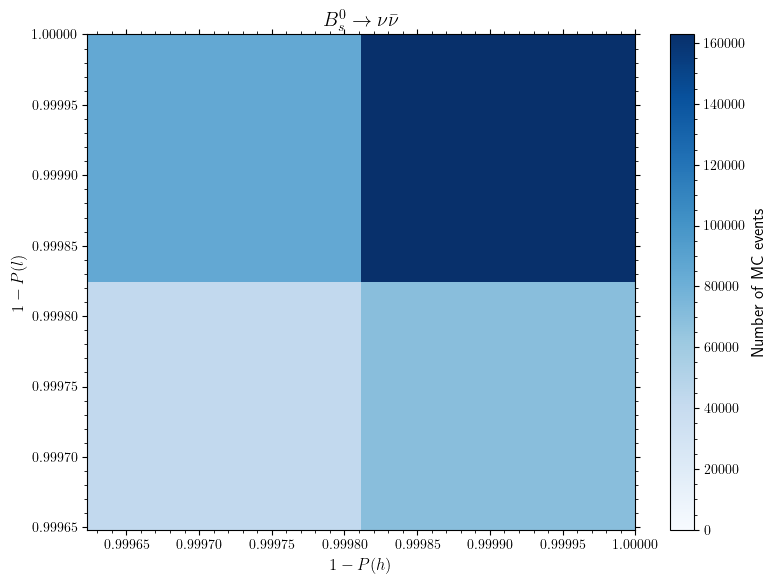

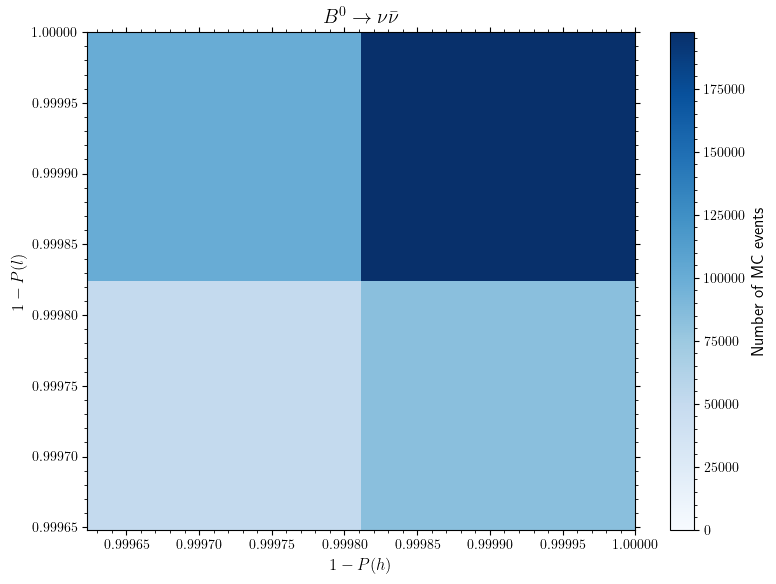

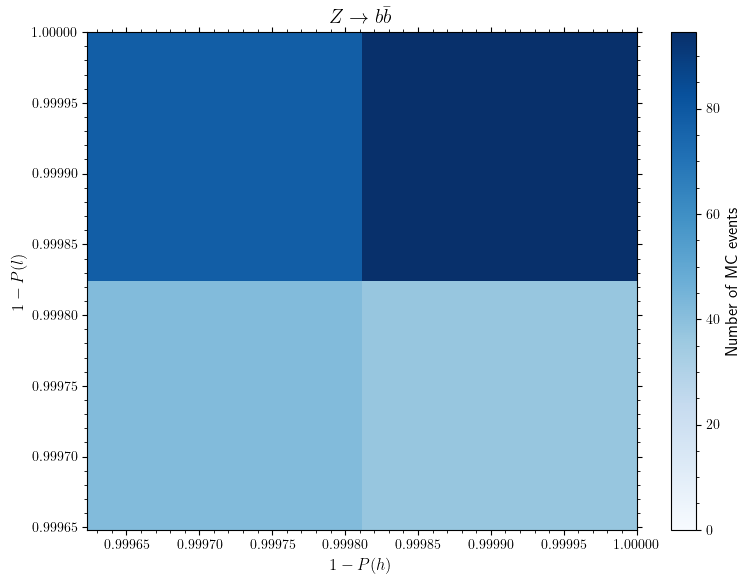

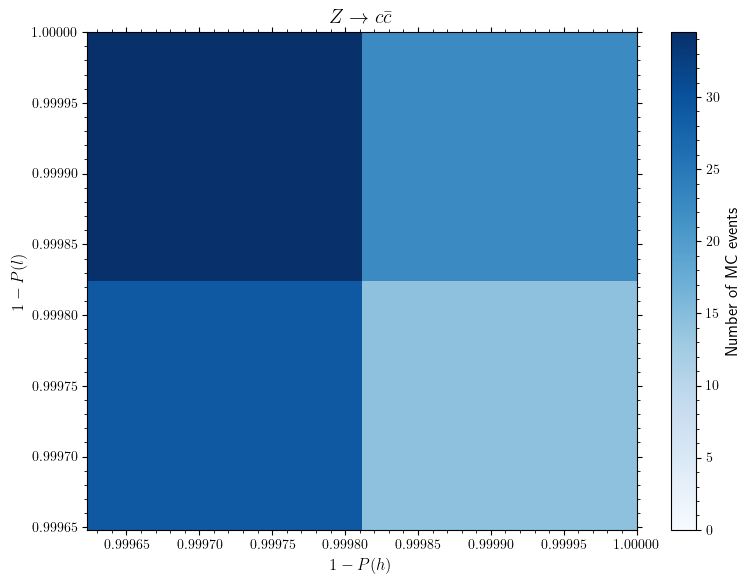

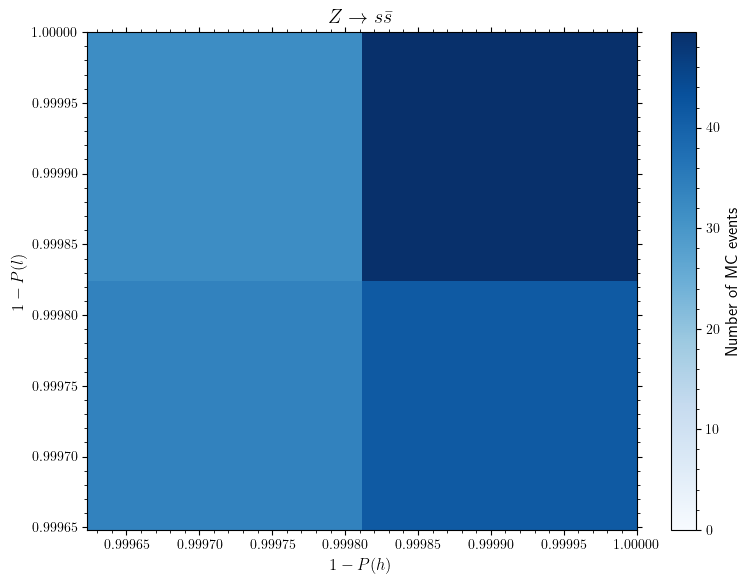

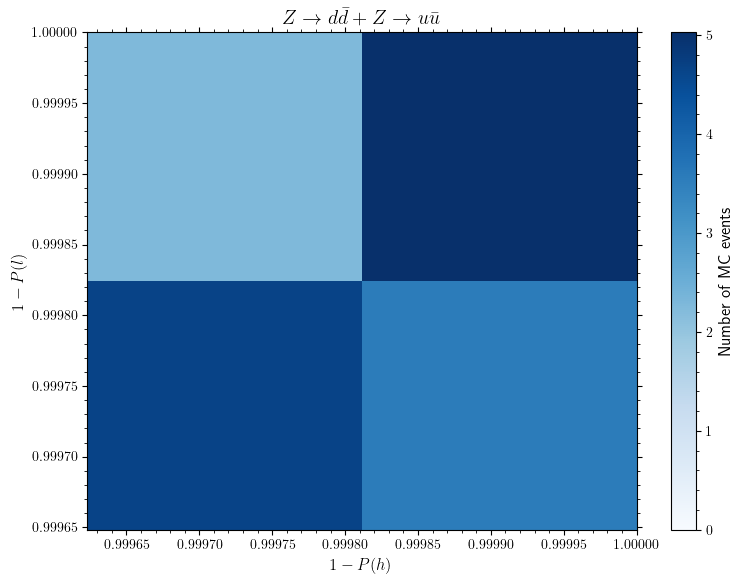

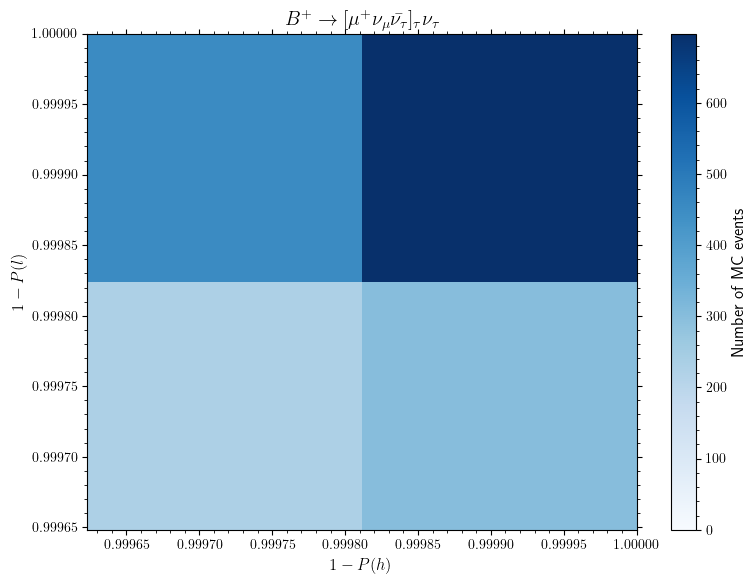

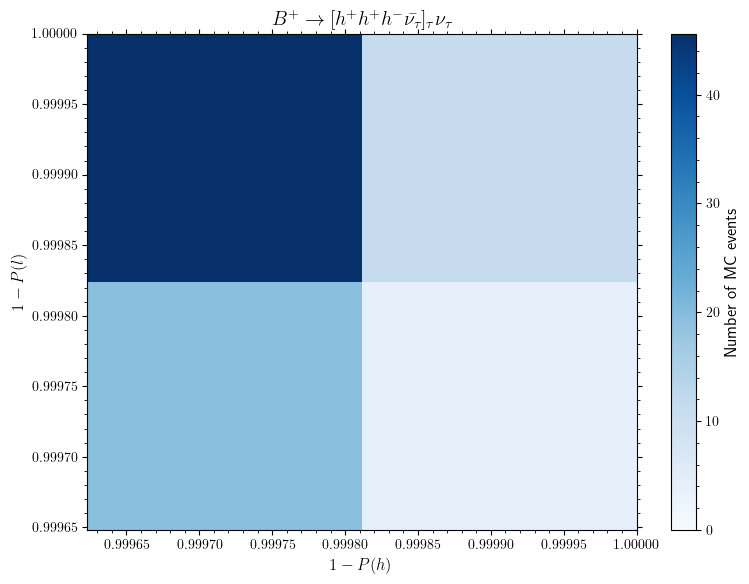

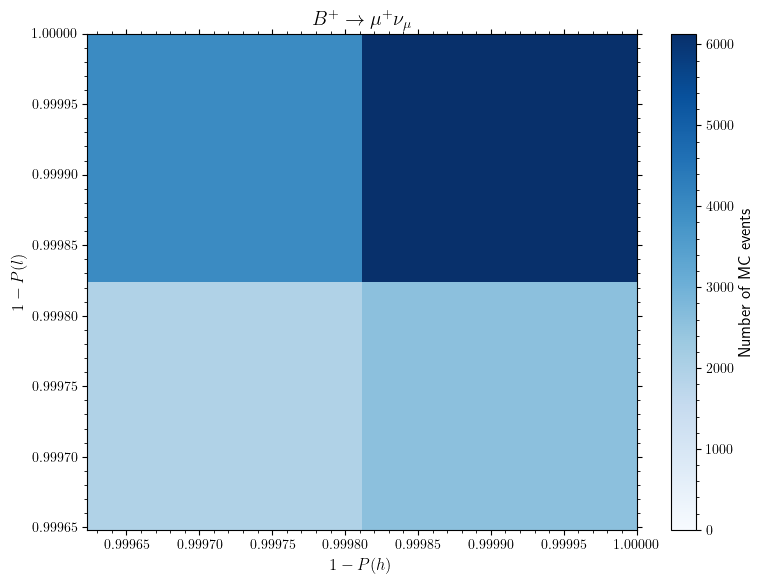

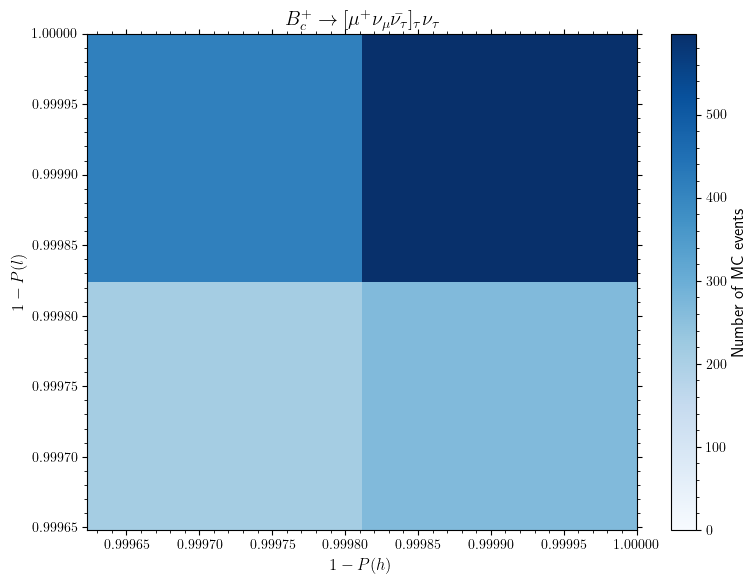

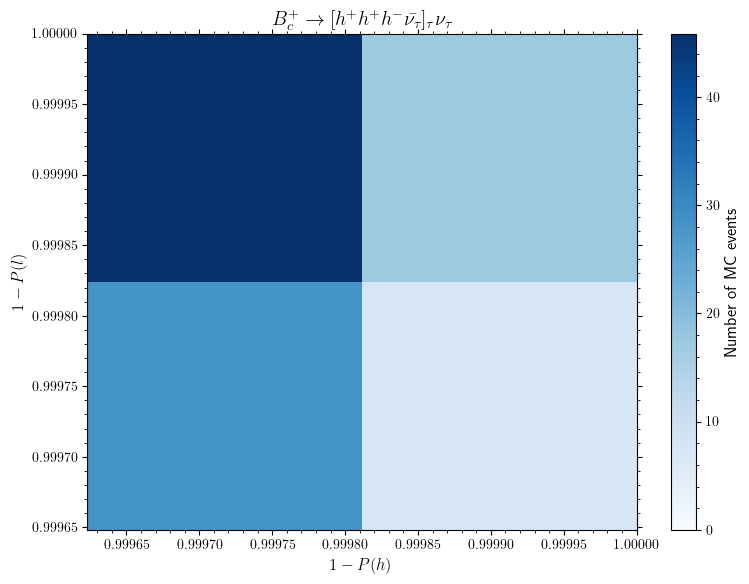

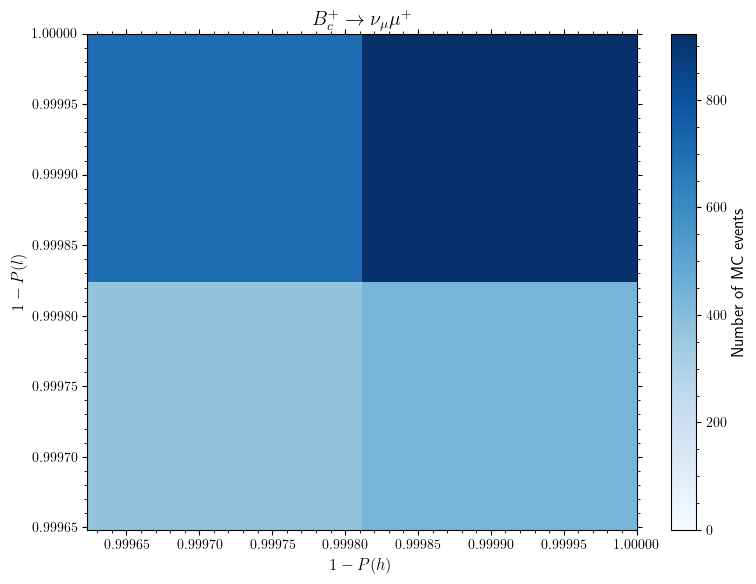

In [3]:
from bdt_lh_cut_opt_significance import run_2d_optimisation, calc_SB_from_opt_cut # note that this has been updated to allow cut_opt_samples input (ie. tell it which samples to run optimisation on)
import matplotlib.pyplot as plt

cut_opt_samples=samples_for_cut_opt 
lrange_interp_N_dict=(0.995,1)
hrange_interp_N_dict=(0.995,1)
nlh = 200 
signal_BF=1e-6
eventsProcessed_dict = cfg.eventsProcessed
histbins=(2,2)
components_to_plot =  ['hadronic_background','combined_signal']
binned_x_axis = np.array([['Signal depleted','Heavy background \n enriched'],['Light background \n enriched','Signal enriched']])


FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict ,hrange_plot=hrange_interp_N_dict, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]


# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])


# Number of events per bin in MC from interpolation 

if histbins != (2,2):
    raise ValueError("Currently only set up for histbins=(2,2)")

else:   
    #bin edges - h on x axis, l on y axis
    h_bins_edges = np.linspace(h_cut, 1, histbins[0] + 1) #x axis
    l_bins_edges = np.linspace(l_cut, 1, histbins[1] + 1)

    
    N_dict_MC = {}

    print('--> Finding number of events per bin')
    #find number of MC events per bin after interpolation
    for sample in interp_N_dict.keys():
        # Grid shape: (histbins[0]+1, histbins[1]+1)
        F = np.zeros((histbins[0] + 1, histbins[1] + 1))

        for ih in range(histbins[0] + 1):
            for il in range(histbins[1] + 1):
                F[ih, il] = interp_N_dict[sample](l_bins_edges[il], h_bins_edges[ih], grid=False)
            # number of events with H > h_cut and L > l_cut
        
        #print(F)
        #print(F[0, 1] )
        #print(F[0, 2] )
        #print(F[1, 1] )
        #print(F[1, 2] )
        
        N_MC = np.zeros((histbins[0], histbins[1]))
        
        for ih in range(histbins[0]):
            for il in range(histbins[1]):

                # finite difference
                N_MC[ih, il] = (
                    F[ih, il]     # bottom-left corner
                    - F[ih+1, il]     # bottom-right
                    - F[ih,   il+1]   # top-left
                    + F[ih+1, il+1]   # top-right (restore overlap)
                    )

    
        N_dict_MC[sample] =  N_MC

        

        '''
        #cut df on optimal BDT cuts
        cut_data = full_data.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')
        h=plt.hist2d(cut_data[cut_data['decay']==sample]["P_not_heavy"], cut_data[cut_data['decay']==sample]["P_not_light"], bins=histbins,cmap=plt.cm.Blues,vmin=0, density=False,range = [[h_cut, 1], [l_cut, 1]])
        print(N_MC)
        print(h[0])
        print("---") 
        print(h_bins_edges)
        print(h[1])
        print("---") 
        print(l_bins_edges)
        print(h[2])
        print("---") 
        
        '''
        
        # Create a figure
        plt.figure(figsize=(8,6))


        # N_MC should match the "grid" of bin edges, so h_bins_edges on x, l_bins_edges on y
        # pcolormesh expects shape (len(y_edges)-1, len(x_edges)-1), so may need to transpose
        plt.pcolormesh(h_bins_edges, l_bins_edges, N_MC.T, shading='auto', cmap=plt.cm.Blues, vmin=0)

        plt.colorbar(label='Number of MC events')
        plt.xlabel('$1-P(h)$')
        plt.ylabel('$1-P(l)$')
        plt.title(cfg.titles[sample])

        plt.show()
        


In [4]:
print(h_bins_edges)
print(l_bins_edges)

[0.99962312 0.99981156 1.        ]
[0.99964824 0.99982412 1.        ]


Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       163.192 |             0.999648 |             0.999623 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
[[ 37.  77.]
 [ 18. 103.]]


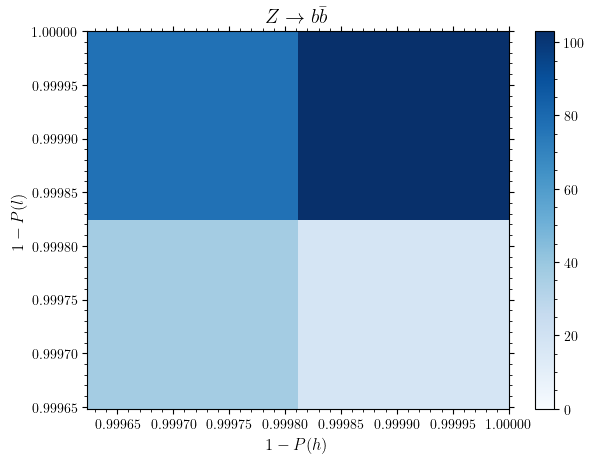

[[37. 35.]
 [ 9. 22.]]


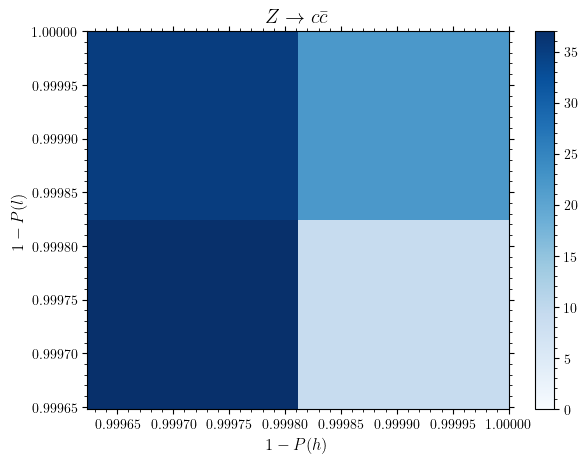

[[35. 23.]
 [36. 58.]]


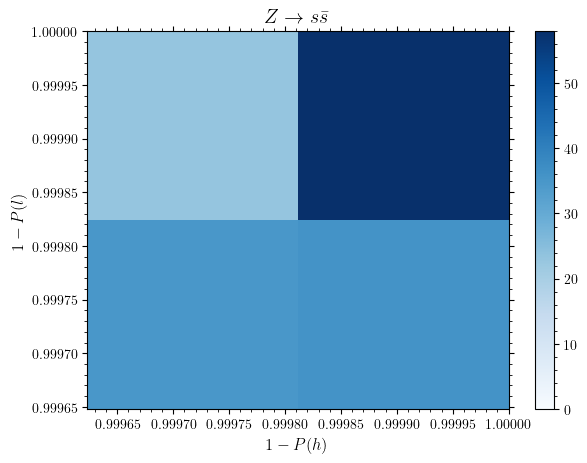

[[5. 3.]
 [6. 3.]]


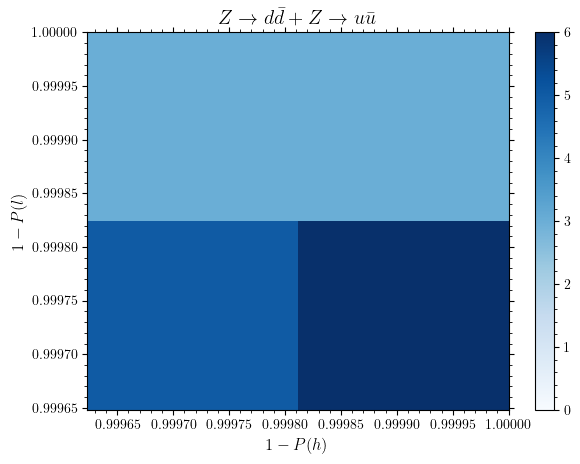

[[ 38676.  82204.]
 [ 33420. 190623.]]


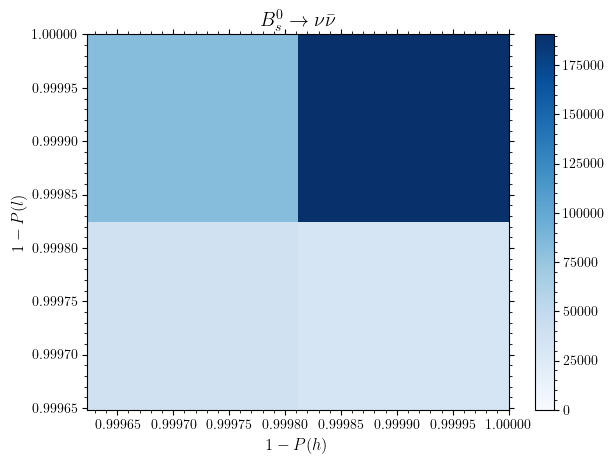

[[ 44805.  95055.]
 [ 39710. 232245.]]


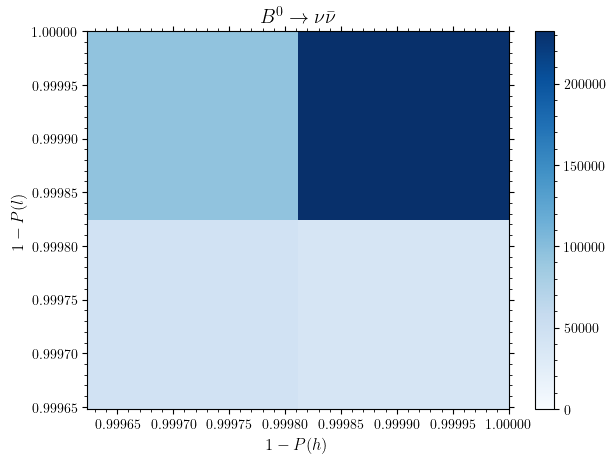

In [5]:
# compate with old version

df = full_data

# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict ,hrange_plot=hrange_interp_N_dict, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]

#cut df on optimal BDT cuts
cut_data = df.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])

print('--> Finding number of events per bin')
# get number of events per bin in MC using np.2d histogram
#N_dict_MC={}


for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    print(h[0])
    plt.ylabel('$1-P(l)$')
    plt.xlabel('$1-P(h)$') 
    plt.title(cfg.titles[decay])
    plt.colorbar(h[3])
    #N_dict_MC[decay] =  h[0] 
    plt.show()


In [6]:
print(h[1])
print(h[2])

[0.99962312 0.99981156 1.        ]
[0.99964824 0.99982412 1.        ]


[[ 0.13564334  0.00895828]
 [ 1.05958547 -0.08218801]]


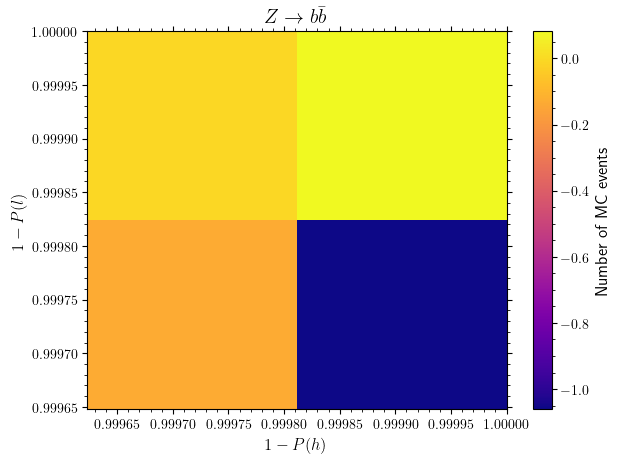

[[-0.21341747 -0.01432731]
 [ 0.58944349  0.02190591]]


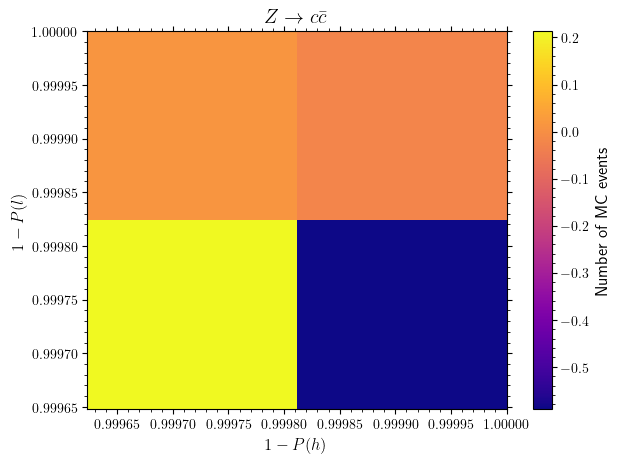

[[-0.02853033  0.38479139]
 [ 0.15183118 -0.1465533 ]]


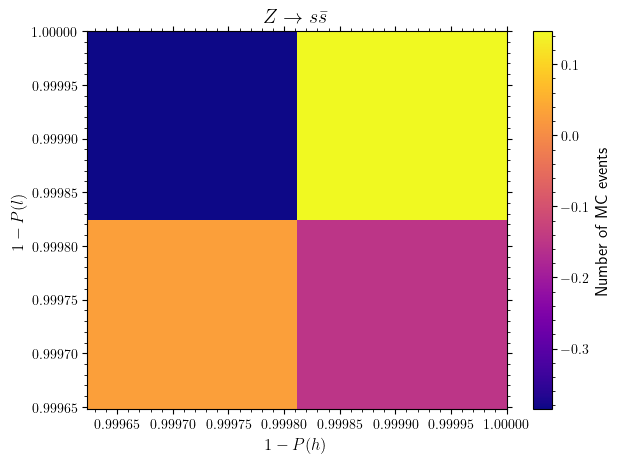

[[-0.06574113 -0.24407483]
 [-0.40657152  0.676095  ]]


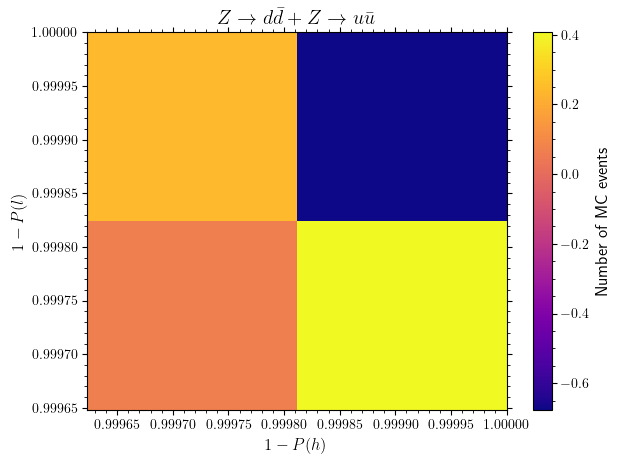

[[ 0.11449601  0.04058754]
 [ 1.08164914 -0.1458899 ]]


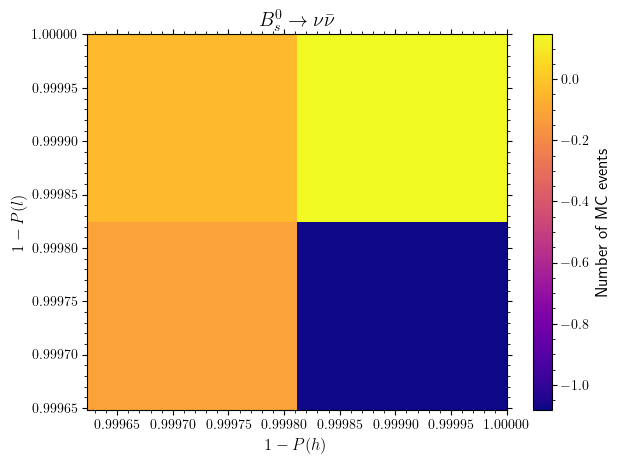

[[ 0.11948822  0.05760595]
 [ 1.11221    -0.14966702]]


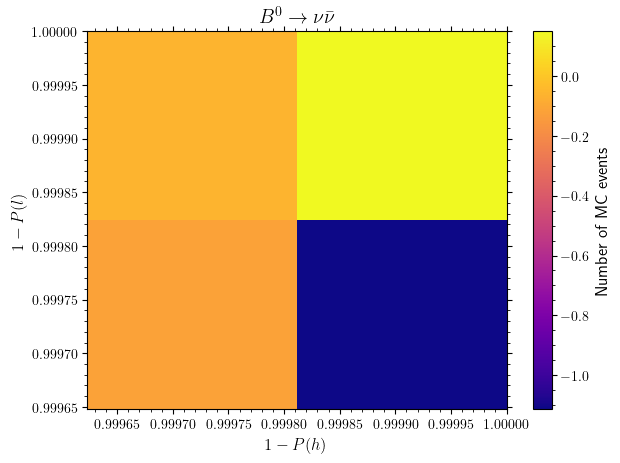

In [9]:
for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC[decay].T)/(h[0].T), shading='auto', cmap='plasma')
    plt.colorbar(label='Fractional difference')
    plt.xlabel('$1-P(h)$')
    plt.ylabel('$1-P(l)$')
    plt.title(cfg.titles[decay])
    #print(N_dict_MC[decay].T)
    #print(h[0].T)
    print((N_dict_MC[decay]-h[0])/(h[0]))
    plt.show()


    


[[ -5.01880371  -0.68978773]
 [-19.07253851   8.46536498]]


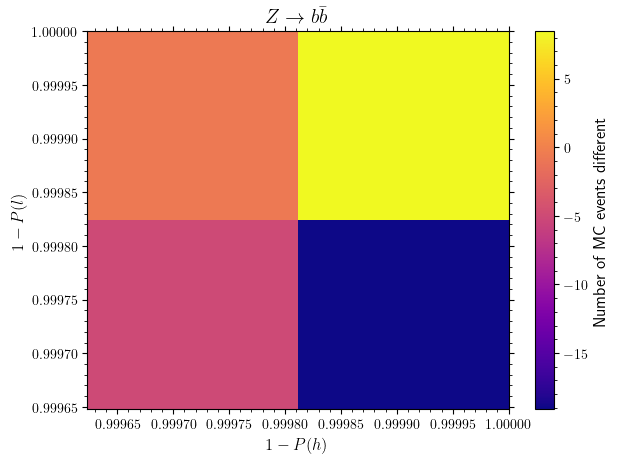

[[ 7.89644644  0.50145576]
 [-5.30499141 -0.48192999]]


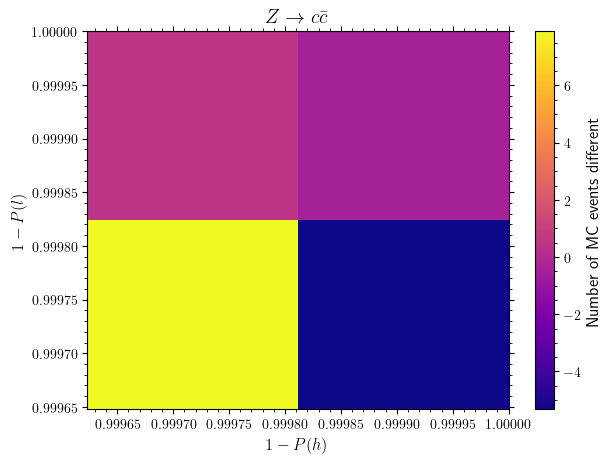

[[ 0.99856158 -8.85020206]
 [-5.46592243  8.50009135]]


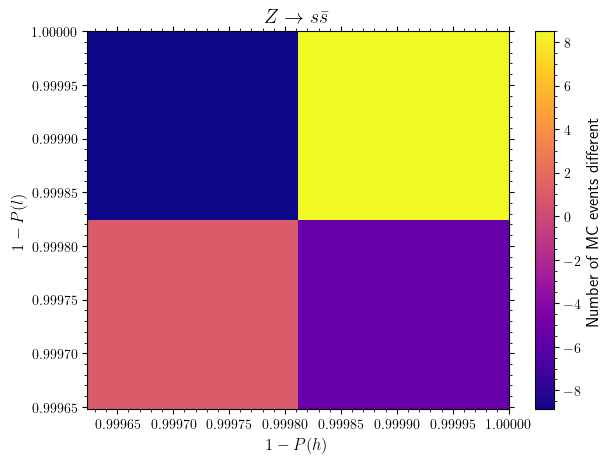

[[ 0.32870563  0.73222448]
 [ 2.43942909 -2.028285  ]]


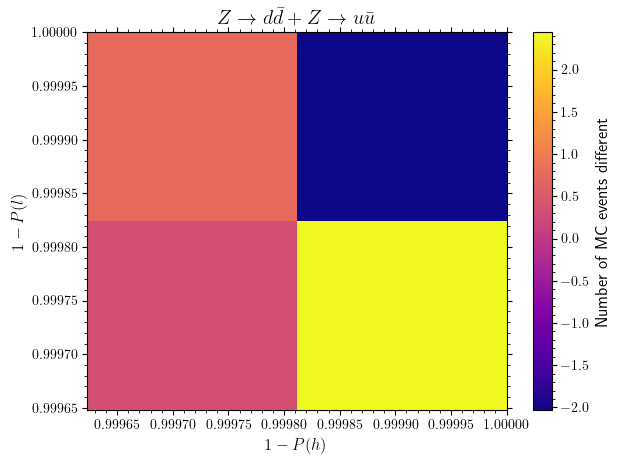

[[ -4428.24777851  -3336.45781759]
 [-36148.71429006  27809.97082287]]


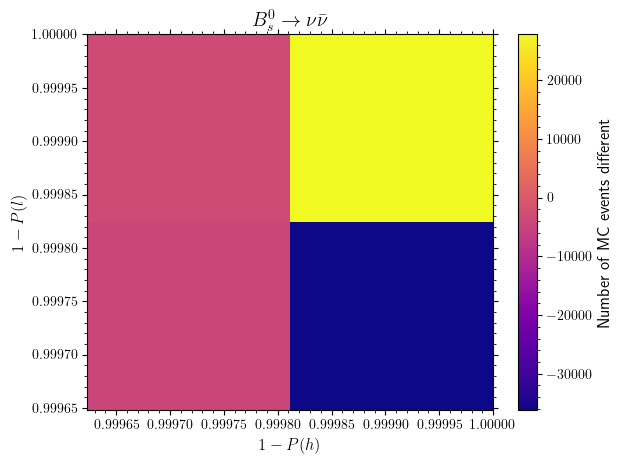

[[ -5353.66957394  -5475.73331158]
 [-44165.85920541  34759.41590374]]


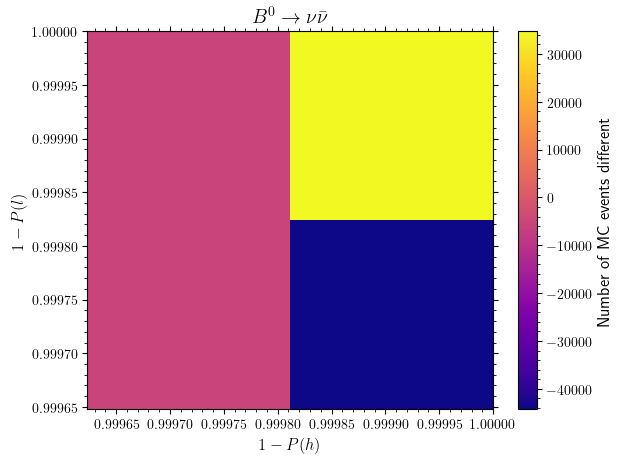

In [11]:
for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC[decay].T), shading='auto', cmap='plasma')
    plt.colorbar(label='Number of MC events different')
    plt.xlabel('$1-P(h)$')
    plt.ylabel('$1-P(l)$')
    plt.title(cfg.titles[decay])
    #print(N_dict_MC[decay].T)
    #print(h[0].T)
    print(-(N_dict_MC[decay]-h[0]))
    plt.show()



### I bleivev the issue here is actually in the splines! Therefore now going to work on them..